In [23]:
from analysis import *
from ellipsoid_fit import *

import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy.spatial.transform import Rotation
np.set_printoptions(precision=3, suppress=True)

In [24]:

def normalize(vec):
    if len(vec.shape) == 1:
        return vec / np.linalg.norm(vec)
    return vec / np.linalg.norm(vec, axis=1, keepdims=True)


In [25]:
# Affine transformation from ellipsoid to unit sphere, keeping the orientation of the axes
def transform(data, center, evecs, radii):  
    # Translate to center
    data = data - center

    # Rotate to align with coordinate axes
    data = np.dot(data, evecs.T)

    # Scale to unit sphere
    for i in range(3):
        data[:, i] /= radii[i]
        
    # Rotate to align with original axes
    data = np.dot(data, evecs)

    return data

In [26]:
import numpy as np

class AffineFinder:
    def __init__(self):
        self.G = np.zeros((12, 12))
        self.h = np.zeros(12)

        self.M = np.eye(3)
        self.c = np.zeros(3)

    def add_sample(self, mag, acc):
        m = np.asarray(mag, dtype=float)
        a = np.asarray(acc, dtype=float)


        m_aug = np.array([m[0], m[1], m[2], 1.0])

        # k corresponds to vec(T) with column-major convention.
        k = np.kron(m_aug, a)

        self.G += np.outer(k, k)
        self.h += k

    def solve(self):
        p = np.linalg.solve(self.G, self.h)

        # Because we used np.kron(m_aug, a), reshape using column-major order.
        T = p.reshape((3, 4), order='F')

        self.M = T[:, :3]
        self.c = T[:, 3]

        return self.M, self.c

    def transform(self, mag):
        m = np.asarray(mag, dtype=float)
        return self.M @ m + self.c

class RotationFinder:
    def __init__(self, target=0.907):
        self.target = target
        self.G = np.zeros((9, 9))  # A^T A
        self.h = np.zeros(9)       # A^T 1
        self.count = 0
        self.R = np.eye(3)
    
    def add_sample(self, mag, acc):
        """Add a single mag/acc pair"""
        m = mag / np.linalg.norm(mag)
        a = acc / np.linalg.norm(acc)
        
        # Kronecker product: m ⊗ a (9-vector)
        # vec(a m^T) in column-major order
        k = np.outer(a, m).ravel('F')  # or equivalently: np.kron(m, a)
        
        self.G += np.outer(k, k)
        self.h += k
        self.count += 1
    
    def solve(self):
        """Solve for rotation matrix"""
        if self.count == 0:
            return False
        
        # Solve G r = target * h
        try:
            r = np.linalg.solve(self.G, self.target * self.h)
        except np.linalg.LinAlgError:
            r = np.linalg.lstsq(self.G, self.target * self.h, rcond=None)[0]
        
        # Reshape to 3x3 (column-major)
        R_raw = r.reshape(3, 3, order='F')
        
        # Project to nearest rotation matrix via SVD
        U, _, Vt = np.linalg.svd(R_raw)
        self.R = U @ Vt
        
        # Ensure proper rotation (det = +1)
        if np.linalg.det(self.R) < 0:
            U[:, -1] *= -1
            self.R = U @ Vt
        
        return True
    
    def evaluate(self, mag, acc):
        """Evaluate dot product for a pair"""
        m = mag / np.linalg.norm(mag)
        a = acc / np.linalg.norm(acc)
        return a @ (self.R @ m)
    
    def reset(self):
        self.G = np.zeros((9, 9))
        self.h = np.zeros(9)
        self.count = 0
        self.R = np.eye(3)


# Test
if __name__ == "__main__":
    S = Rotation.random().as_matrix()
    v0 = np.array([0.0, 0.0, -1.0])
    v1 = np.array([0.4135656507192516, -0.08036317018458757, 0.9069207316094637])
    target = v0 @ v1
    finder = RotationFinder(target=target)

    noise_sigma = 0.1

    acc = []
    mag = []
    for i in range(1000):
        R = Rotation.random().as_matrix()
        w0 = R @ v0 + np.random.randn(3) * noise_sigma
        w1 = S @ R @ v1 + np.random.randn(3) * noise_sigma
        acc.append(normalize(w0))
        mag.append(normalize(w1))

        finder.add_sample(w0, w1)


    print("Actual Rotation matrix S:")
    print(S)

    if finder.solve():
        print("\nRotation matrix R:")
        print(finder.R)
    

Actual Rotation matrix S:
[[ 0.111  0.899 -0.424]
 [-0.762  0.351  0.545]
 [ 0.638  0.262  0.724]]

Rotation matrix R:
[[ 0.106  0.9   -0.423]
 [-0.749  0.352  0.562]
 [ 0.654  0.257  0.711]]


In [27]:
def load_data():
    data = process_file_to_raw_data("magacc_readings_7.txt")
    mag = data[:,:3]
    acc = data[:,3:]

    norm = np.linalg.norm(acc, 2, axis=1)
    idcs = np.isclose(norm, 9.8, atol=0.4)

    mag = mag[idcs]
    acc = acc[idcs]

    mag = np.array(mag)
    acc = np.array(acc)
    return mag, acc



In [28]:
mag, acc = load_data()

points = sphere_raw = mag
center, R, radii = fit_ellipsoid_standard(points)
params = solution_to_params(center, R, radii)

# center, R, radii = fit_ellipsoid_l2(points, params)

sphere_transformed = transform(sphere_raw, center, R, radii)

In [29]:
acc

array([[-0.997,  9.433,  1.841],
       [-0.077,  6.825,  6.825],
       [-0.153,  7.976,  5.291],
       ...,
       [-0.537,  7.515,  6.518],
       [-0.153,  4.141,  8.972],
       [-0.077,  1.227,  9.586]], shape=(2328, 3))

In [30]:
AF = AffineFinder()

mag, acc = load_data()


for m,a in zip(mag, acc):
    AF.add_sample(m, a / 9.8 / -0.907)
    
R, c = AF.solve()

detrans = -np.array([R @ m + c for m in mag])

print(R)
print(c)


[[ 0.01  -0.003  0.003]
 [ 0.001  0.015 -0.002]
 [ 0.     0.     0.014]]
[-0.024  0.111 -0.589]


In [31]:
print(R.tolist())
print(c.tolist())

[[0.009832802786855563, -0.003315360925796289, 0.003002534463870098], [0.0014788530614671172, 0.015317432954948884, -0.0018616256109190384], [0.00034790291126295505, 0.00031379922696547703, 0.013520461421269859]]
[-0.02411581504531156, 0.11089214298101935, -0.589216677713465]


In [32]:
%matplotlib inline

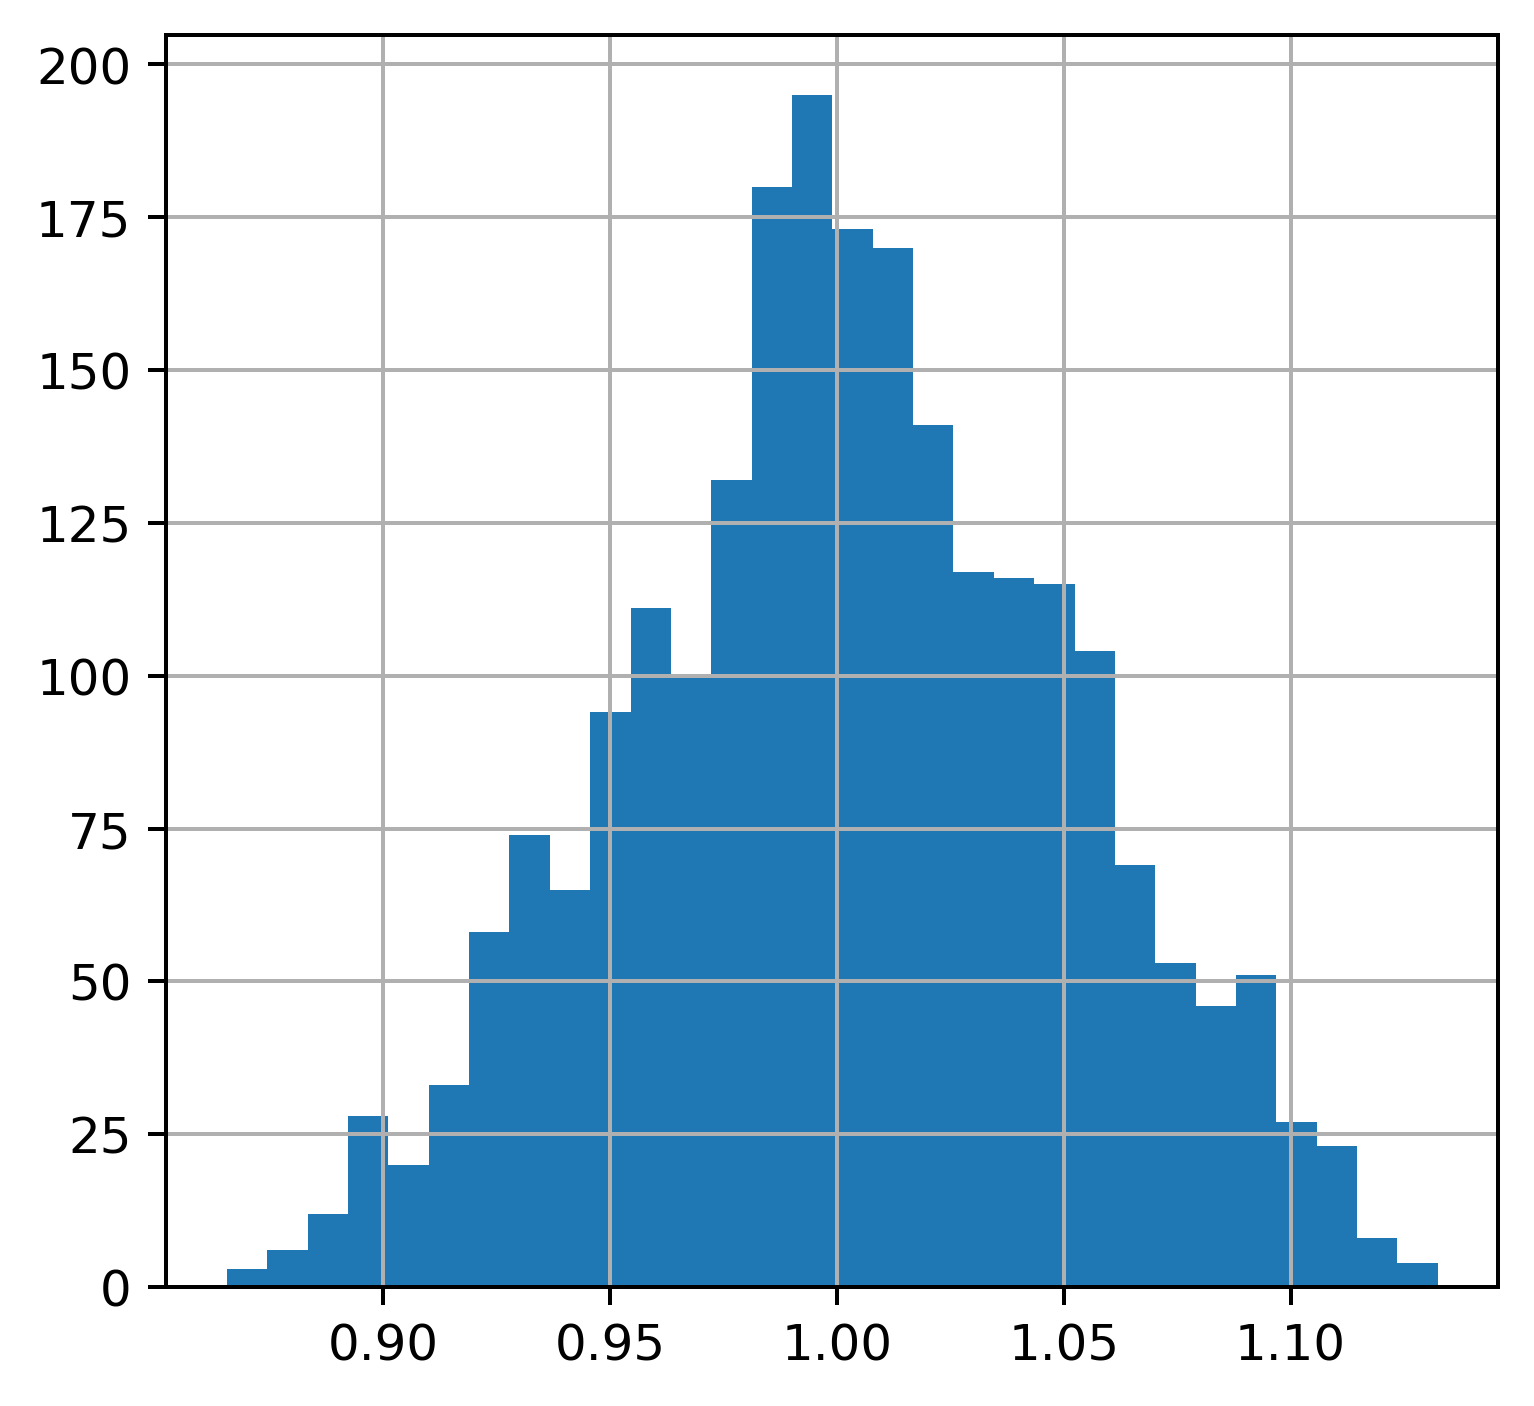

In [33]:
norms = np.array([ np.linalg.norm(m) for m,a in zip(detrans, acc)])
plt.clf()
plt.hist(norms, 30)
plt.grid()
plt.show()

In [34]:
dots = np.array([a / np.linalg.norm(a) @ m for m,a in zip(detrans, acc)])
print(np.mean(dots))
print(np.std(dots))

0.9132766933893779
0.02933151071897976


In [35]:
np.linalg.norm(detrans, axis=1)

array([1.026, 0.922, 0.947, ..., 1.013, 1.011, 0.963], shape=(2328,))

In [36]:
%matplotlib widget

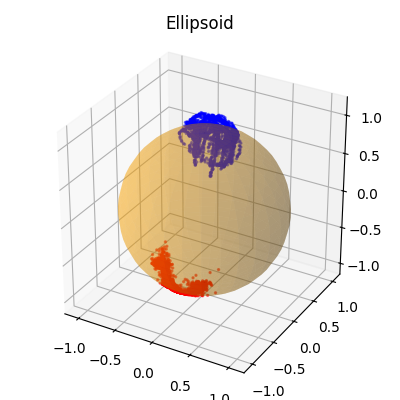

In [37]:
# gravity frame
acc_normalized = -acc / np.linalg.norm(acc, axis=1, keepdims=True)
detrans_normalized = detrans # / np.linalg.norm(detrans, axis=1, keepdims=True)

fig = plt.figure(figsize=(4, 4))

ax1 = fig.add_subplot(111, projection='3d')
ax1.scatter(*detrans_normalized.T, c='blue', marker='o', s=2, alpha=0.5, label='Sphere Raw')
plot_ellipsoid(ax1)
set_axes_equal(ax1)

ax1.scatter(*acc_normalized.T, c='red', marker='o', s=2, alpha=0.5, label='Accel')


plt.tight_layout()
plt.show()

In [ ]:
v_acc = np.array([0.4135656507192516, -0.08036317018458757, -0.9069207316094637])
v_mag = np.array([0., 0., 1.])